# Lab work - 2.1

## Q1: Coin Toss & Dice Simulation
- Simulate fair coin toss and dice roll
- Visualize frequency
- Verify Law of Large Numbers

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Coin toss simulation
coin = np.random.choice(['H', 'T'], size=1000)
coin_counts = pd.Series(coin).value_counts(normalize=True)
coin_counts

H    0.513
T    0.487
Name: proportion, dtype: float64

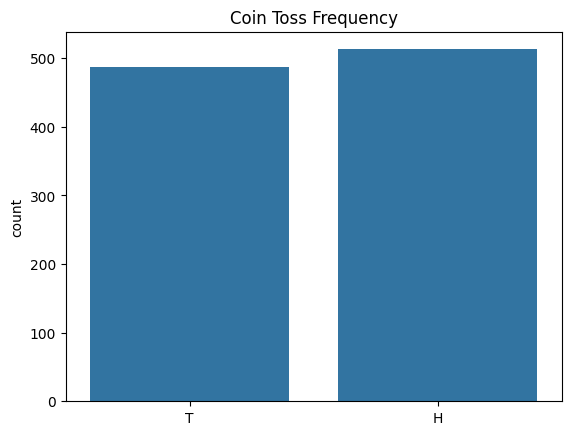

In [3]:
sns.countplot(x=coin)
plt.title('Coin Toss Frequency')
plt.show()

In [4]:
# Dice roll simulation
dice = np.random.randint(1, 7, size=1000)
dice_probs = pd.Series(dice).value_counts(normalize=True).sort_index()
dice_probs

1    0.163
2    0.176
3    0.162
4    0.164
5    0.168
6    0.167
Name: proportion, dtype: float64

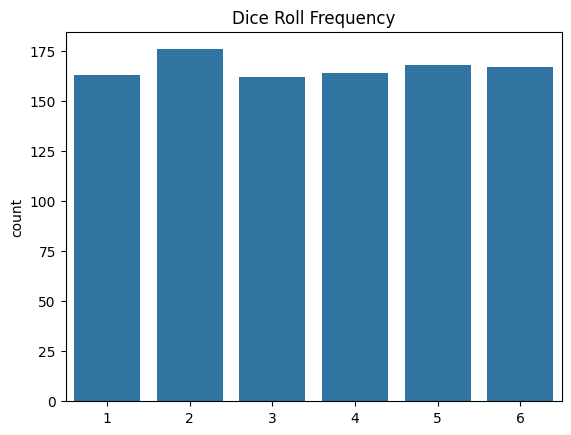

In [5]:
sns.countplot(x=dice)
plt.title('Dice Roll Frequency')
plt.show()

### Law of Large Numbers Verification

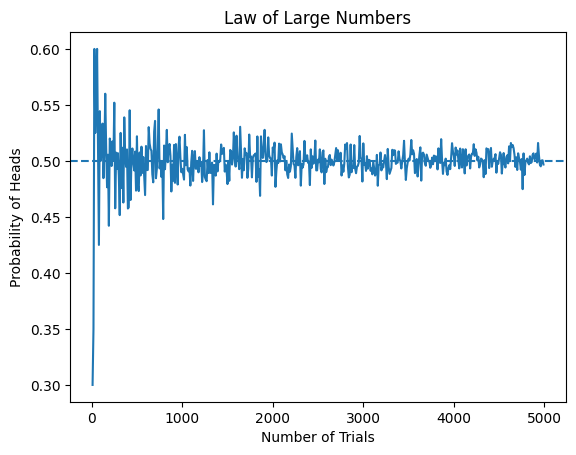

In [6]:
trials = np.arange(10, 5000, 10)
head_prob = []

for t in trials:
    tosses = np.random.choice(['H', 'T'], size=t)
    head_prob.append(np.mean(tosses == 'H'))

plt.plot(trials, head_prob)
plt.axhline(0.5, linestyle='--')
plt.xlabel('Number of Trials')
plt.ylabel('Probability of Heads')
plt.title('Law of Large Numbers')
plt.show()

## Q2: Sample Space of Two Coins

In [7]:
sample_space = pd.DataFrame([
    ('H', 'H'), ('H', 'T'), ('T', 'H'), ('T', 'T')
], columns=['Coin1', 'Coin2'])
sample_space

,Coin1,Coin2
0,H,H
1,H,T
2,T,H
3,T,T


In [8]:
one_head = sample_space[(sample_space == 'H').sum(axis=1) == 1]
prob_one_head = len(one_head) / len(sample_space)
prob_one_head

0.5

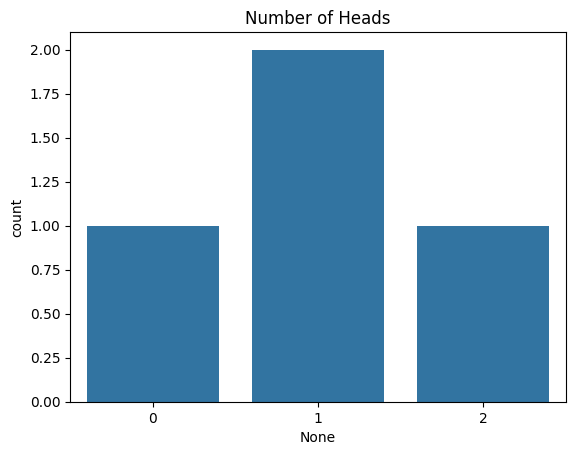

In [9]:
sns.countplot(x=(sample_space == 'H').sum(axis=1))
plt.title('Number of Heads')
plt.show()

## Q3: Probability Using DataFrame (Cards / Student Data)

In [10]:
students = pd.DataFrame({
    'Gender': ['M','F','M','F','M','F','M','F'],
    'Marks': [85, 72, 90, 60, 88, 95, 55, 78],
    'Stream': ['Sci','Com','Sci','Arts','Sci','Sci','Arts','Com']
})
students

,Gender,Marks,Stream
0,M,85,Sci
1,F,72,Com
2,M,90,Sci
3,F,60,Arts
4,M,88,Sci
5,F,95,Sci
6,M,55,Arts
7,F,78,Com


In [11]:
# Probability of student scoring > 80
prob_gt_80 = len(students[students['Marks'] > 80]) / len(students)
prob_gt_80

0.5

In [12]:
# Compound event (Science AND >80)
compound_prob = len(students[(students['Stream'] == 'Sci') & (students['Marks'] > 80)]) / len(students)
compound_prob

0.5

## Q4: Empirical vs Theoretical Probability

In [13]:
# Coin toss empirical probability
coin = np.random.choice(['H','T'], size=1000)
empirical_p = np.mean(coin == 'H')
theoretical_p = 0.5

empirical_p, theoretical_p

(np.float64(0.493), 0.5)

In [14]:
# Two dice sum = 7
dice1 = np.random.randint(1,7,10000)
dice2 = np.random.randint(1,7,10000)
empirical_sum7 = np.mean(dice1 + dice2 == 7)
theoretical_sum7 = 6/36

empirical_sum7, theoretical_sum7

(np.float64(0.1665), 0.16666666666666666)

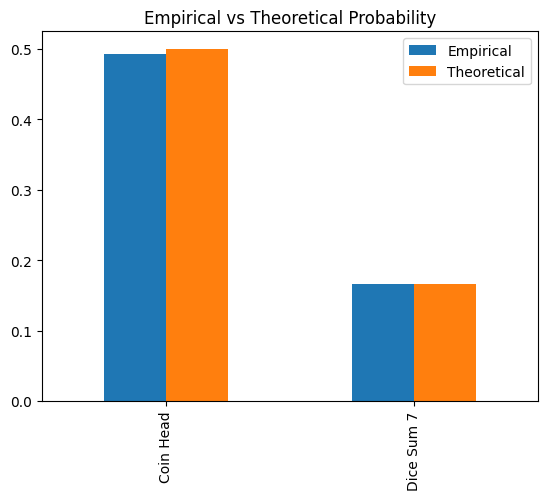

In [15]:
events = ['Coin Head', 'Dice Sum 7']
empirical = [empirical_p, empirical_sum7]
theoretical = [theoretical_p, theoretical_sum7]

df = pd.DataFrame({'Empirical': empirical, 'Theoretical': theoretical}, index=events)
df.plot(kind='bar')
plt.title('Empirical vs Theoretical Probability')
plt.show()